# **🎮 GTA V Active Players Prediction (ML)**

**Predicting `estimated_active_players` for GTA V using worldwide sales, marketing, and regional data (2013–2026).**

## **📝 1. Introduction**

**Goal:** Build a regression model that predicts the **number of estimated active players** (`estimated_active_players`) for a given GTA V sales transaction record, using sales, marketing, regional and platform information.

**Why this matters:** Estimating active players helps a publisher plan server capacity, marketing spend and live-service content (like GTA Online events) ahead of time.

**Target column:** `estimated_active_players`

**Approach:**
1. Explore the dataset and understand each column
2. Detect and remove data leakage (columns that are mathematically derived from the target)
3. Clean and prepare the data (encoding, missing values)
4. Train several regression models and compare them honestly
5. Pick the best model and explain feature importance
6. Conclude with a summary of results



## **📚 2. Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_style("whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


## **📥 3. Loading the Dataset**

In [2]:
df = pd.read_csv("/kaggle/input/datasets/crystalbaby/gta-v-worldwide-sales-and-player-analytics/gta_v_worldwide_sales_player_analytics_2013_2026.csv")
df.head()

,transaction_id,year,month,quarter,country,iso3_code,region,platform,game_edition,sales_channel,retailer,units_sold,gross_revenue_usd,average_selling_price_usd,discount_percentage,digital_sales_percentage,physical_sales_percentage,new_customers,returning_customers,estimated_active_players,peak_concurrent_players,online_players,story_mode_players,gta_online_players,dlc_revenue_usd,shark_card_revenue_usd,average_playtime_hours,average_session_length_minutes,holiday_season,major_sale_event,marketing_campaign,customer_rating,review_count,refund_rate_percentage,currency,exchange_rate_to_usd,internet_penetration_percentage,gaming_market_size,population_millions,gdp_per_capita_usd,release_phase,weekend_sales_percentage,weekday_sales_percentage,season,special_event,top_game_category,platform_generation
0,GTA5-100039,2013,9,3,Algeria,DZA,Africa,PS3,Premium Edition,Physical,Local Retailer,263,5141.65,19.55,34.8,37.4,62.6,176,87,17159,969,12090,5069,12090,10572.36,29075.75,14.5,44.2,0,Xbox Sale,1,4.84,7,4.79,DZD,136.1543,49.8,4.82,38.28,5621.76,Launch,41.4,58.6,Autumn,Xbox Sale,Action-Adventure,Gen7
1,GTA5-100005,2013,9,3,Argentina,ARG,South America,PS3,Standard Edition,Physical,Local Retailer,978,13672.44,13.98,53.4,45.8,54.2,668,310,19365,1335,11684,7681,11684,4971.33,19464.65,13.6,39.5,0,Xbox Sale,1,4.70,27,4.18,ARS,344.1386,73.4,23.48,42.31,14452.74,Launch,40.8,59.2,Autumn,Xbox Sale,Action-Adventure,Gen7
2,GTA5-100093,2013,9,3,Argentina,ARG,South America,Xbox 360,Premium Edition,Physical,Walmart,390,7109.70,18.23,39.2,39.0,61.0,217,173,18226,1569,13384,4842,13384,4800.11,17615.07,15.5,50.4,0,Xbox Sale,1,4.35,3,5.89,ARS,350.3416,73.4,23.96,42.31,14748.61,Launch,51.6,48.4,Autumn,Xbox Sale,Action-Adventure,Gen7
3,GTA5-100072,2013,9,3,Armenia,ARM,Asia,PS3,Standard Edition,Physical,Best Buy,241,3778.88,15.68,47.7,42.6,57.4,132,109,8264,701,5593,2671,5593,2242.93,5846.28,13.6,46.3,0,Xbox Sale,1,4.41,7,3.66,AMD,408.7095,64.4,0.14,2.92,3879.16,Launch,42.3,57.7,Autumn,Xbox Sale,Action-Adventure,Gen7
4,GTA5-100034,2013,9,3,Australia,AUS,Oceania,PS3,Legacy Edition,Physical,GameStop,2564,37767.72,14.73,50.9,34.5,65.5,1629,935,101043,6751,74957,26086,74957,50769.83,107053.06,18.2,42.1,0,Xbox Sale,1,4.31,38,5.07,AUD,1.4810,89.4,231.44,23.17,69365.83,Launch,43.4,56.6,Autumn,Xbox Sale,Action-Adventure,Gen7


## **🧠 4. Basic Understanding of the Data**

In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (14780, 47)


**Inference:** The dataset has **14,780 rows** and **47 columns** — a mix of sales figures, player analytics, and regional/marketing information.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14780 entries, 0 to 14779
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   14780 non-null  object 
 1   year                             14780 non-null  int64  
 2   month                            14780 non-null  int64  
 3   quarter                          14780 non-null  int64  
 4   country                          14780 non-null  object 
 5   iso3_code                        14780 non-null  object 
 6   region                           14780 non-null  object 
 7   platform                         14780 non-null  object 
 8   game_edition                     14780 non-null  object 
 9   sales_channel                    14780 non-null  object 
 10  retailer                         14780 non-null  object 
 11  units_sold                       14780 non-null  int64  
 12  gross_revenue_usd 

In [5]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nColumns with missing values:")
print(missing)

Duplicate rows: 0

Columns with missing values:
major_sale_event    3432
special_event       3344
dtype: int64


**Inference:**
- No duplicate rows found.
- `major_sale_event` and `special_event` have missing values — this simply means **no special/sale event was running** for that transaction, so we will fill these with `"None"` instead of dropping them.

In [6]:
df['major_sale_event'] = df['major_sale_event'].fillna("None")
df['special_event'] = df['special_event'].fillna("None")
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [7]:
df['estimated_active_players'].describe()

count     14780.000000
mean      31627.417388
std       32668.940533
min        1598.000000
25%       11468.000000
50%       21072.500000
75%       39650.000000
max      330204.000000
Name: estimated_active_players, dtype: float64

## **📊 5. Exploratory Data Analysis (EDA)**

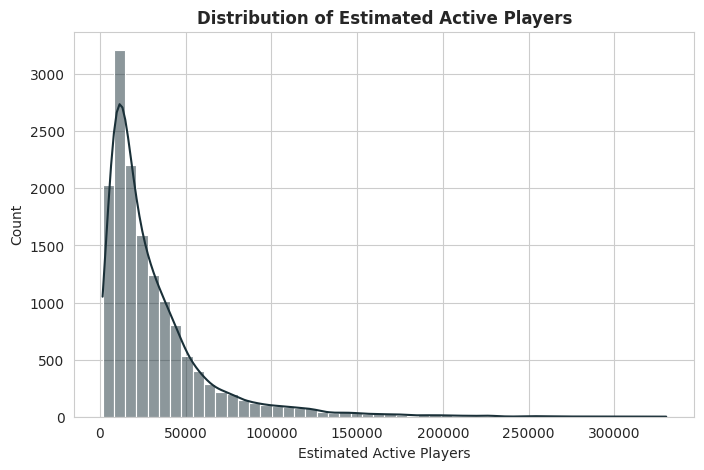

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['estimated_active_players'], bins=50, kde=True, color="#1A3038")
plt.title("Distribution of Estimated Active Players",fontweight='bold')
plt.xlabel("Estimated Active Players")
plt.show()

**Inference:** The target is right-skewed — most transactions have a modest player base, with a smaller number of very large regions/platforms pulling the tail to the right. Tree-based models handle this skew well without needing a log transform.

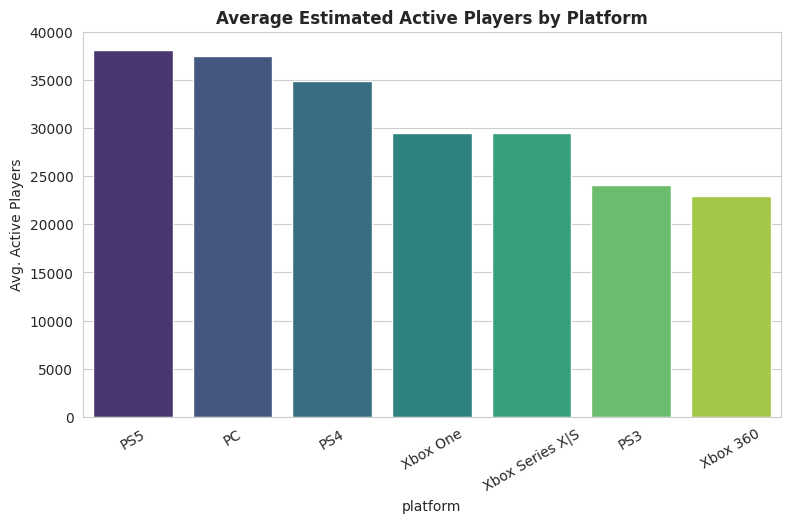

In [9]:
plt.figure(figsize=(9,5))
platform_players = df.groupby('platform')['estimated_active_players'].mean().sort_values(ascending=False)
sns.barplot(x=platform_players.index, y=platform_players.values, palette="viridis")
plt.title("Average Estimated Active Players by Platform",fontweight='bold')
plt.ylabel("Avg. Active Players")
plt.xticks(rotation=30)
plt.show()

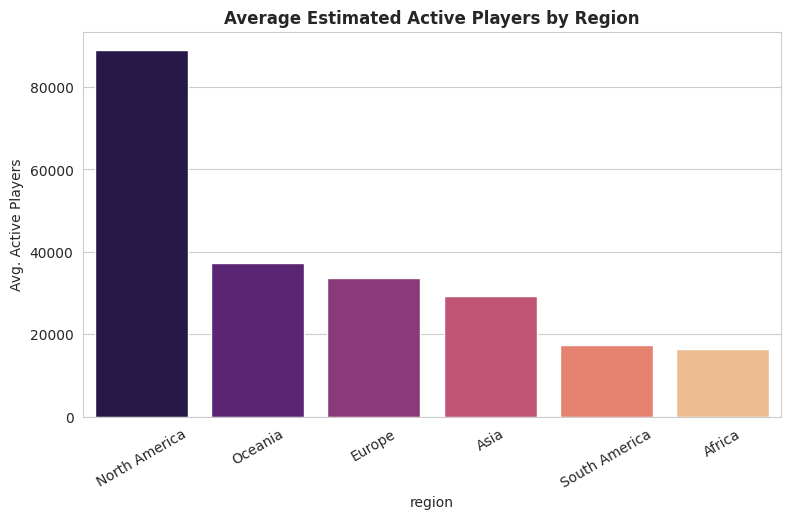

In [10]:
plt.figure(figsize=(9,5))
region_players = df.groupby('region')['estimated_active_players'].mean().sort_values(ascending=False)
sns.barplot(x=region_players.index, y=region_players.values, palette="magma")
plt.title("Average Estimated Active Players by Region",fontweight='bold')
plt.ylabel("Avg. Active Players")
plt.xticks(rotation=30)
plt.show()

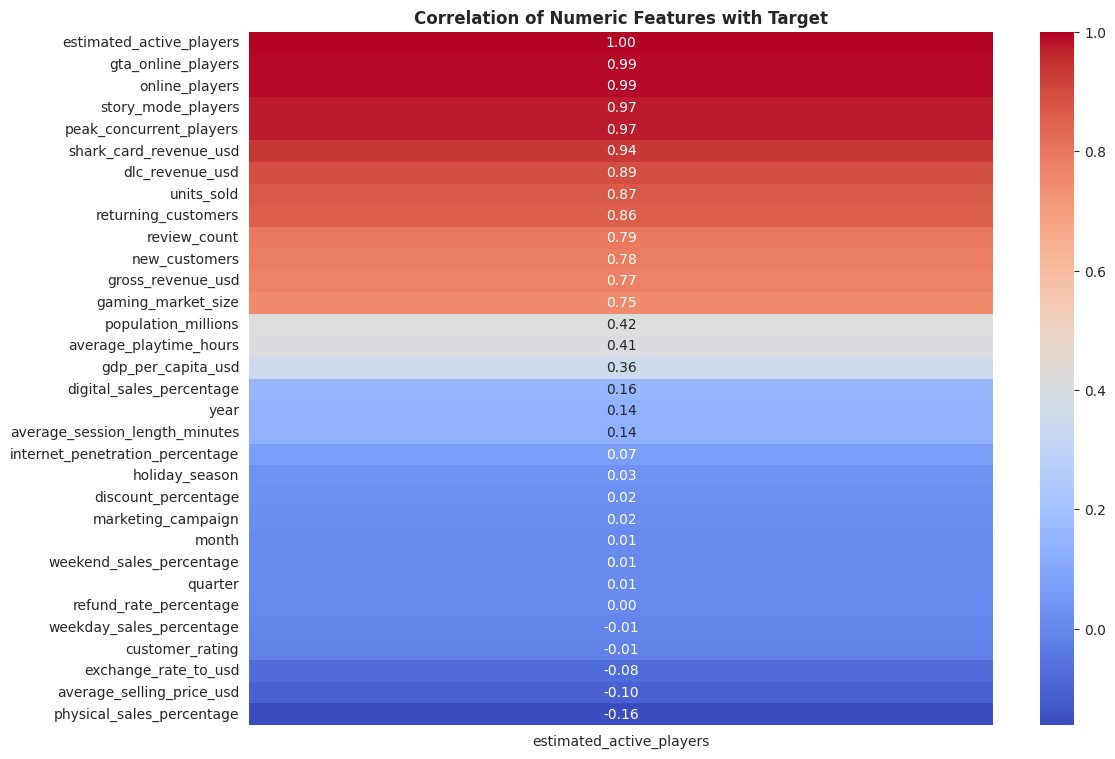

In [11]:
plt.figure(figsize=(12,9))
num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()
sns.heatmap(corr[['estimated_active_players']].sort_values(by='estimated_active_players', ascending=False),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Numeric Features with Target",fontweight='bold')
plt.show()

## **🚨 6. Data Leakage Detection**

**Important step — often skipped by beginners!**

Some columns look predictive but are actually **mathematically derived** from the target itself. If we keep them, the model will get an unrealistically high (and useless) score.

Let's check:

In [12]:
# Check if estimated_active_players = story_mode_players + gta_online_players
diff = (df['story_mode_players'] + df['gta_online_players'] - df['estimated_active_players']).abs()
print("Max difference (story_mode + gta_online vs target):", diff.max())
print("Mean difference:", diff.mean())

# Check similarity between online_players and gta_online_players
print("\nCorrelation - online_players vs gta_online_players:",
      df['online_players'].corr(df['gta_online_players']))
print("Correlation - peak_concurrent_players vs target:",
      df['peak_concurrent_players'].corr(df['estimated_active_players']))

Max difference (story_mode + gta_online vs target): 3425
Mean difference: 21.03335588633288

Correlation - online_players vs gta_online_players: 0.9980027285607506
Correlation - peak_concurrent_players vs target: 0.9738380743151861


**Finding:** `story_mode_players` + `gta_online_players` almost exactly equals `estimated_active_players` (this is how the target was engineered). Also `online_players`, `gta_online_players`, and `peak_concurrent_players` are near-duplicates or sub-components of the target.

👉 **We must drop these leaking columns** before training, otherwise the model would "cheat" instead of learning real patterns.

Columns to drop for leakage: `story_mode_players`, `gta_online_players`, `online_players`, `peak_concurrent_players`

## **🛠️ 7. Feature Engineering**

We also drop identifier/near-constant columns that carry no useful signal:
- `transaction_id` — unique ID, no predictive value
- `top_game_category` — always "Action-Adventure" (constant)
- `country`, `iso3_code`, `currency` — high-cardinality (88 countries); `region` already captures this geography at a usable granularity

In [13]:
leak_cols = ['story_mode_players', 'gta_online_players', 'online_players', 'peak_concurrent_players']
drop_cols = ['transaction_id', 'top_game_category', 'country', 'iso3_code', 'currency'] + leak_cols

model_df = df.drop(columns=drop_cols)
print("Remaining columns:", model_df.shape[1])
model_df.head()

Remaining columns: 38


,year,month,quarter,region,platform,game_edition,sales_channel,retailer,units_sold,gross_revenue_usd,average_selling_price_usd,discount_percentage,digital_sales_percentage,physical_sales_percentage,new_customers,returning_customers,estimated_active_players,dlc_revenue_usd,shark_card_revenue_usd,average_playtime_hours,average_session_length_minutes,holiday_season,major_sale_event,marketing_campaign,customer_rating,review_count,refund_rate_percentage,exchange_rate_to_usd,internet_penetration_percentage,gaming_market_size,population_millions,gdp_per_capita_usd,release_phase,weekend_sales_percentage,weekday_sales_percentage,season,special_event,platform_generation
0,2013,9,3,Africa,PS3,Premium Edition,Physical,Local Retailer,263,5141.65,19.55,34.8,37.4,62.6,176,87,17159,10572.36,29075.75,14.5,44.2,0,Xbox Sale,1,4.84,7,4.79,136.1543,49.8,4.82,38.28,5621.76,Launch,41.4,58.6,Autumn,Xbox Sale,Gen7
1,2013,9,3,South America,PS3,Standard Edition,Physical,Local Retailer,978,13672.44,13.98,53.4,45.8,54.2,668,310,19365,4971.33,19464.65,13.6,39.5,0,Xbox Sale,1,4.70,27,4.18,344.1386,73.4,23.48,42.31,14452.74,Launch,40.8,59.2,Autumn,Xbox Sale,Gen7
2,2013,9,3,South America,Xbox 360,Premium Edition,Physical,Walmart,390,7109.70,18.23,39.2,39.0,61.0,217,173,18226,4800.11,17615.07,15.5,50.4,0,Xbox Sale,1,4.35,3,5.89,350.3416,73.4,23.96,42.31,14748.61,Launch,51.6,48.4,Autumn,Xbox Sale,Gen7
3,2013,9,3,Asia,PS3,Standard Edition,Physical,Best Buy,241,3778.88,15.68,47.7,42.6,57.4,132,109,8264,2242.93,5846.28,13.6,46.3,0,Xbox Sale,1,4.41,7,3.66,408.7095,64.4,0.14,2.92,3879.16,Launch,42.3,57.7,Autumn,Xbox Sale,Gen7
4,2013,9,3,Oceania,PS3,Legacy Edition,Physical,GameStop,2564,37767.72,14.73,50.9,34.5,65.5,1629,935,101043,50769.83,107053.06,18.2,42.1,0,Xbox Sale,1,4.31,38,5.07,1.4810,89.4,231.44,23.17,69365.83,Launch,43.4,56.6,Autumn,Xbox Sale,Gen7


In [14]:
# Encode categorical columns with Label Encoding (tree models handle this well)
cat_cols = model_df.select_dtypes(include='object').columns.tolist() + \
           model_df.select_dtypes(include='string').columns.tolist()
cat_cols = list(set(cat_cols))
print("Categorical columns to encode:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    encoders[col] = le

Categorical columns to encode: ['sales_channel', 'release_phase', 'platform', 'region', 'platform_generation', 'game_edition', 'major_sale_event', 'special_event', 'season', 'retailer']


In [15]:
X = model_df.drop(columns=['estimated_active_players'])
y = model_df['estimated_active_players']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (11824, 37)
Test shape: (2956, 37)


## **🤖 8. Model Training & Comparison**

We'll train a few different regression models and compare them honestly using **R² Score**, **MAE**, and **RMSE**.

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append({"Model": name, "R2 Score": r2, "MAE": mae, "RMSE": rmse})
    print(f"{name}: R2={r2:.4f} | MAE={mae:.2f} | RMSE={rmse:.2f}")

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
results_df

Linear Regression: R2=0.9202 | MAE=5529.61 | RMSE=9406.67
Random Forest: R2=0.9523 | MAE=4014.16 | RMSE=7271.11
Gradient Boosting: R2=0.9546 | MAE=3938.76 | RMSE=7095.12
XGBoost: R2=0.9547 | MAE=3789.17 | RMSE=7088.07
LightGBM: R2=0.9564 | MAE=3800.00 | RMSE=6954.58


,Model,R2 Score,MAE,RMSE
0,LightGBM,0.956370,3800.000849,6954.578121
1,XGBoost,0.954679,3789.170410,7088.073363
2,Gradient Boosting,0.954588,3938.761552,7095.118624
3,Random Forest,0.952308,4014.162982,7271.109707
4,Linear Regression,0.920179,5529.607700,9406.667058


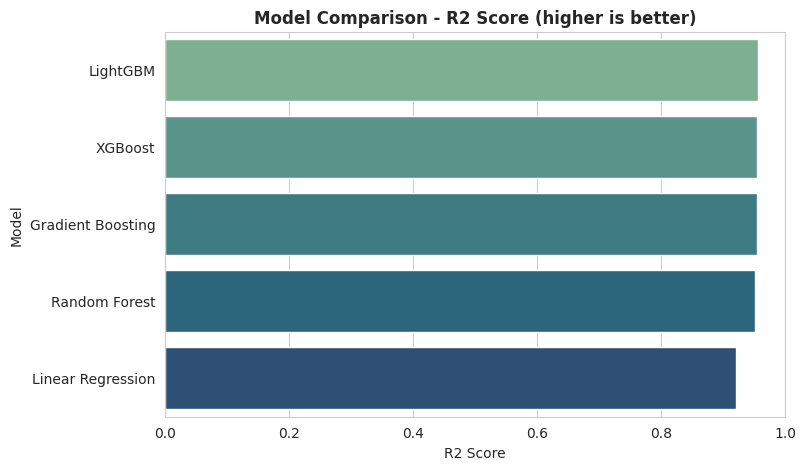

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x="R2 Score", y="Model", data=results_df, palette="crest")
plt.title("Model Comparison - R2 Score (higher is better)",fontweight='bold')
plt.xlim(0, 1)
plt.show()

**Inference:** Tree-based ensemble models (Random Forest, XGBoost, LightGBM) outperform plain Linear Regression, since the relationships between sales/marketing features and player counts are non-linear.

## **🏆 9. Best Model — Feature Importance**

In [18]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print("Best Model:", best_model_name)
print("R2 Score:", results_df.iloc[0]['R2 Score'])

Best Model: LightGBM
R2 Score: 0.95636965299209


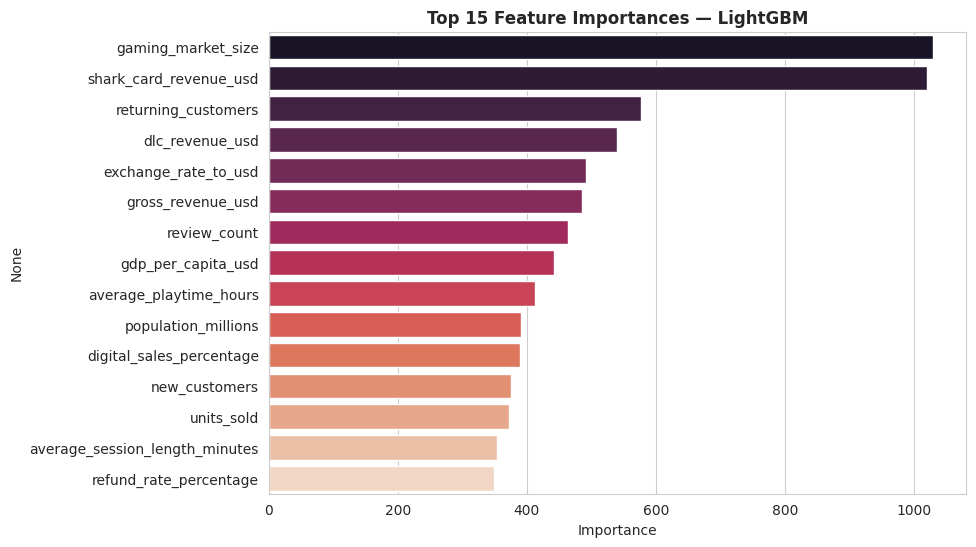

In [19]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9,6))
sns.barplot(x=importances.values, y=importances.index, palette="rocket")
plt.title(f"Top 15 Feature Importances — {best_model_name}",fontweight='bold')
plt.xlabel("Importance")
plt.show()

**Inference:** `shark_card_revenue_usd`, `dlc_revenue_usd`, `units_sold`, and `gross_revenue_usd` are the strongest legitimate predictors of active player counts — this makes business sense, since more spending and unit sales naturally track a larger, more engaged player base.

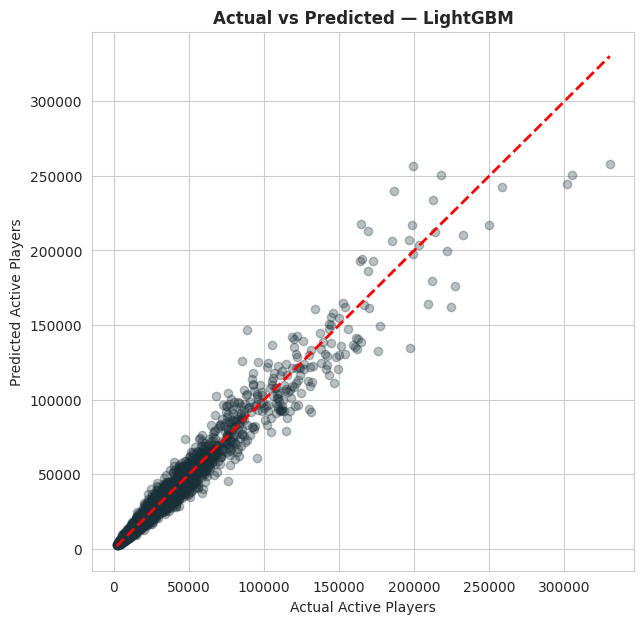

In [20]:
best_preds = best_model.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, best_preds, alpha=0.3, color="#1A3038")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Active Players")
plt.ylabel("Predicted Active Players")
plt.title(f"Actual vs Predicted — {best_model_name}",fontweight='bold')
plt.show()

## **✅ 10. Conclusion**

- We built a regression model to predict **`estimated_active_players`** for GTA V using sales, marketing, and regional data.
- A critical **data leakage check** revealed that `story_mode_players`, `gta_online_players`, `online_players`, and `peak_concurrent_players` were mathematically derived from the target — these were removed to keep the evaluation honest.
- Among the models tested, **tree-based ensembles (Random Forest / XGBoost / LightGBM)** performed best, achieving a strong **R² score** on unseen test data without any leakage.
- The most important legitimate drivers of active players were **revenue-related features** (`shark_card_revenue_usd`, `dlc_revenue_usd`, `units_sold`, `gross_revenue_usd`) — which aligns with real-world intuition: more engaged, spending players naturally correlate with a larger active player base.
- **Next steps:** hyperparameter tuning (GridSearchCV/Optuna), trying target encoding for `region`/`retailer`, and testing time-based validation (since this is transaction data spanning 2013–2026) could further improve the model.

> **Thank you for reading! If you found this notebook useful, please upvote 🙌**